In [2]:
import numpy as np

In [30]:
uwb_pos = np.random.rand(4, 2) * 10  # UWB anchor positions
true_pos = np.random.rand(2) * 10  # True position of the object
distances = np.linalg.norm(uwb_pos - true_pos, axis=1) + np.random.normal(0, 0.1, size=4)  # Add some noise to the distances

def residual(x: np.ndarray, uwb_pos: np.ndarray, distances: np.ndarray) -> np.ndarray:
    return np.linalg.norm(uwb_pos - x, axis=1) - distances

def jacobian(x: np.ndarray, uwb_pos: np.ndarray) -> np.ndarray:
    diff_uwb = x - uwb_pos
    norm_uwb = np.linalg.norm(diff_uwb, axis=1, keepdims=True)
    jacobian_matrix = diff_uwb / norm_uwb
    
    return jacobian_matrix

def gauss_newton(
    x0: np.ndarray,
    uwb_pos: np.ndarray,
    distances: np.ndarray,
    max_iter: int = 15,
    tol: float = 1e-6
):
    x = x0.copy()
    gn_history = [x.copy()]
    for _ in range(max_iter):
        r = residual(x, uwb_pos, distances)
        J = jacobian(x, uwb_pos)
        H = J.T @ J
        g = J.T @ r
        dx = np.linalg.solve(H, -g)
        x += dx
        gn_history.append(x.copy())
        if np.linalg.norm(dx) < tol:
            break
    return x, np.array(gn_history)

def levenberg_marquardt(
    x0: np.ndarray,
    uwb_pos: np.ndarray,
    distances: np.ndarray,
    max_iter: int = 15,
    tol: float = 1e-6,
    damp: float = 1
):
    x = x0.copy()
    lm_history = [x.copy()]
    for _ in range(max_iter):
        r = residual(x, uwb_pos, distances)
        J = jacobian(x, uwb_pos)
        H = J.T @ J + damp * np.eye(J.shape[1])
        g = J.T @ r
        cost = 0.5 * r.T @ r
        dx = np.linalg.solve(H, -g)
        x += dx
        r_new = residual(x, uwb_pos, distances)
        cost_new = 0.5 * r_new.T @ r_new
        df_pred = 0.5 * dx.T @ (damp * dx - g)
        df_actual = cost - cost_new
        rho = df_actual / df_pred if df_pred != 0 else 0
        if rho > 0:
            damp *= max(1 / 3, 1 - (2 * rho - 1) ** 3)
        else:
            damp *= 2
            x -= dx
        lm_history.append(x.copy())
        if np.linalg.norm(dx) < tol:
            break
    return x, np.array(lm_history)

x0 = np.random.rand(2)  # Initial guess for the position
gn_est, gn_history = gauss_newton(x0, uwb_pos, distances)
lm_est, lm_history = levenberg_marquardt(x0, uwb_pos, distances)

print("True Position:", true_pos, "GN Estimated Position:", gn_est, "LM Estimated Position:", lm_est)
print("GN History:", gn_history)
print("LM History:", lm_history)

True Position: [5.5287752  3.77196765] GN Estimated Position: [5.61100496 3.78232506] LM Estimated Position: [5.61100496 3.78232506]
GN History: [[0.71690121 0.8109917 ]
 [5.25495241 2.04367677]
 [6.08212701 3.49478793]
 [5.63546774 3.77233044]
 [5.61107971 3.78213109]
 [5.61100587 3.78232193]
 [5.61100498 3.78232501]
 [5.61100496 3.78232506]]
LM History: [[0.71690121 0.8109917 ]
 [3.33083734 2.56691309]
 [4.27000809 3.19252126]
 [5.65424421 3.6595287 ]
 [5.61553373 3.7779414 ]
 [5.61106137 3.78221392]
 [5.61100564 3.78232296]
 [5.61100497 3.78232502]
 [5.61100496 3.78232506]]


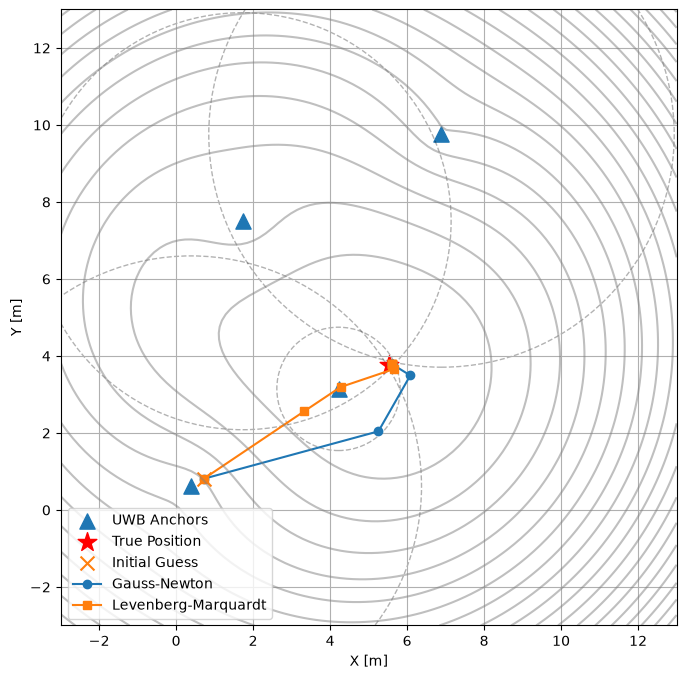

In [33]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

def plot_uwb_scene(
    uwb_pos,
    distances,
    true_pos,
    x0,
    gn_history,
    lm_history
):
    fig, ax = plt.subplots(figsize=(8, 8))

    # UWB anchors
    ax.scatter(
        uwb_pos[:, 0],
        uwb_pos[:, 1],
        marker="^",
        s=120,
        label="UWB Anchors"
    )

    # 测距圆
    for anchor, distance in zip(uwb_pos, distances):
        circle = plt.Circle(
            anchor,
            distance,
            fill=False,
            linestyle="--",
            alpha=0.3
        )
        ax.add_patch(circle)

    # True position
    ax.scatter(
        true_pos[0],
        true_pos[1],
        marker="*",
        s=200,
        color="red",
        label="True Position"
    )

    # Initial position
    ax.scatter(
        x0[0],
        x0[1],
        marker="x",
        s=100,
        label="Initial Guess"
    )

    # GN trajectory
    ax.plot(
        gn_history[:, 0],
        gn_history[:, 1],
        marker="o",
        label="Gauss-Newton"
    )

    # LM trajectory
    ax.plot(
        lm_history[:, 0],
        lm_history[:, 1],
        marker="s",
        label="Levenberg-Marquardt"
    )

    # Contour
    def cost_function(x):
        r = residual(x, uwb_pos, distances)
        return 0.5 * r.T @ r

    x_range = np.linspace(-3, 13, 100)
    y_range = np.linspace(-3, 13, 100)
    X, Y = np.meshgrid(x_range, y_range)
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = cost_function(np.array([X[i, j], Y[i, j]]))

    ax.contour(X, Y, Z, levels=20, colors="gray", alpha=0.5)

    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")

    ax.set_aspect("equal")
    ax.grid(True)
    ax.legend()

    ax.set_xlim(-3, 13)
    ax.set_ylim(-3, 13)

    plt.show()

plot_uwb_scene(
    uwb_pos=uwb_pos,
    distances=distances,
    true_pos=true_pos,
    x0=x0,
    gn_history=gn_history,
    lm_history=lm_history
)